In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import datetime
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Data laoding
orders_df = pd.read_excel('Superstore_Data.xlsx', sheet_name='Orders')
returns_df = pd.read_excel('Superstore_Data.xlsx', sheet_name='Returns')

In [4]:
# Merge order and returns data
data = pd.merge(orders_df, returns_df, on='Order ID', how='left')

In [5]:
# Exclude returned orders
data = data[data['Returned'] != 'Yes']

In [8]:
if not pd.api.types.is_datetime64_any_dtype(data['Order Date']):
    try:
        data['Order Date'] = pd.to_datetime(data['Order Date'])
    except:
        print("Detected Excel serial dates, converting...")
        base_date = datetime.datetime(1899, 12, 30)
        data['Order Date'] = pd.to_timedelta(data['Order Date'], unit='D') + base_date

In [9]:
# Aggregate sales by date
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.set_index('Order Date', inplace=True)

In [10]:
# Resampled to daily data, missing dates filled with zeros.
daily_sales = daily_sales.resample('D').sum().fillna(0)

In [11]:
# Data Preprocessing for LSTM
# Normalise data to the range 0–1
scaler = MinMaxScaler(feature_range=(0, 1))
sales_data = scaler.fit_transform(daily_sales['Sales'].values.reshape(-1, 1))

# Create Sliding Windows
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 30  # Use monthly data to predict
X, y = create_sequences(sales_data, SEQ_LENGTH)

# Turn X, y to Tensor
X = torch.FloatTensor(X)
y = torch.FloatTensor(y)

# Split by 80%
train_size = int(len(y) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

In [14]:
# Model Definition
class SalesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(SalesLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # LSTM output like: (batch, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        # Retrieve the output from the last time step
        last_time_step = lstm_out[:, -1, :]
        predictions = self.linear(last_time_step)
        return predictions

model = SalesLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
# Training
epochs = 100
print("Start training ...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}')

Start training ...
Epoch 10/100, Loss: 0.005629
Epoch 20/100, Loss: 0.005629
Epoch 30/100, Loss: 0.005628
Epoch 40/100, Loss: 0.005635
Epoch 50/100, Loss: 0.005629
Epoch 60/100, Loss: 0.005627
Epoch 70/100, Loss: 0.005626
Epoch 80/100, Loss: 0.005625
Epoch 90/100, Loss: 0.005624
Epoch 100/100, Loss: 0.005623


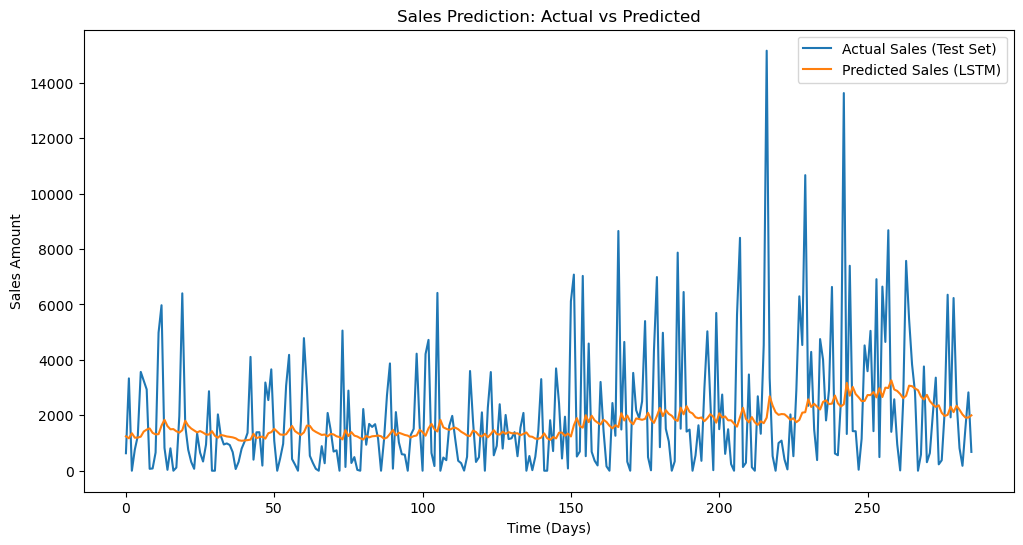

In [18]:
# Prediction & Visualization
model.eval()
with torch.no_grad():
    test_predict = model(X_test)

# de-normalisation
test_predict_inv = scaler.inverse_transform(test_predict.numpy())
y_test_inv = scaler.inverse_transform(y_test.numpy())

# Drawing plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual Sales (Test Set)')
plt.plot(test_predict_inv, label='Predicted Sales (LSTM)')
plt.title('Sales Prediction: Actual vs Predicted')
plt.xlabel('Time (Days)')
plt.ylabel('Sales Amount')
plt.legend()
plt.show()